In [1]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_moons
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_curve, roc_auc_score)

RANDOM_STATE = 42
plt.rcParams["figure.dpi"] = 110
print("Ready.")

Ready.


In [3]:
try:
    import seaborn as sns
    df = sns.load_dataset("titanic")
except Exception:
    df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv")

print("Rows, columns:", df.shape)
df.head()

Rows, columns: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [5]:
print(df.shape
      )

(891, 15)


{0: 549, 1: 342}
Survival rate: 0.3838383838383838 3


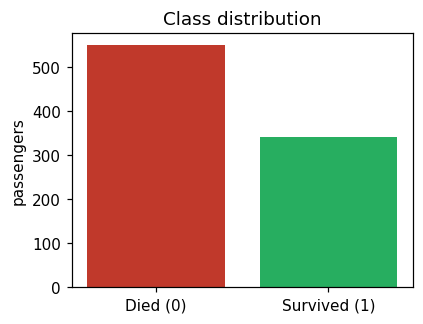

In [6]:
counts = df['survived'].value_counts().sort_index()
print(counts.to_dict())

print("Survival rate:", round(df['survived']).mean(),3)
plt.figure(figsize=(4,3))
plt.bar(['Died (0)','Survived (1)'], counts.values, color=['#c0392b','#27ae60'])
plt.title("Class distribution"); plt.ylabel("passengers"); plt.show()

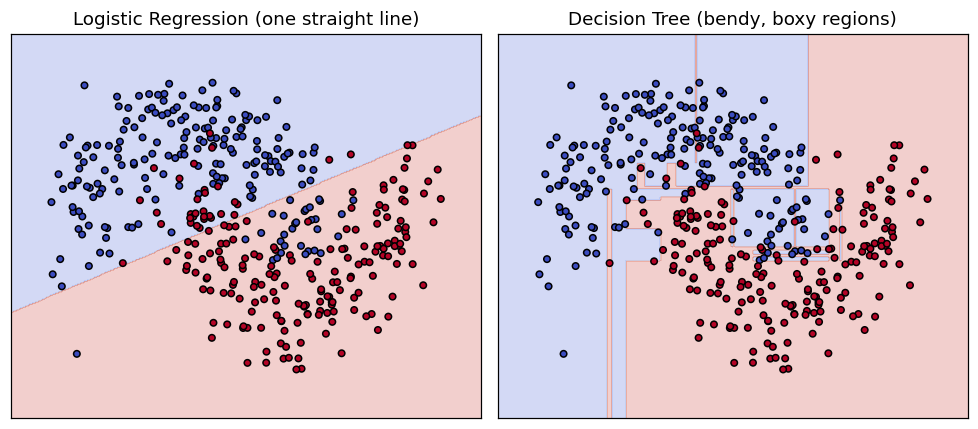

In [7]:
# using the concept of linear / straight line - to find out the problem
Xm, ym = make_moons(n_samples=400, noise=0.25, random_state=RANDOM_STATE)
def plot_boundary(model, X, y, title, ax):
    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(X[:,0].min()-.4, X[:,0].max()+.4, 300),
                         np.linspace(X[:,1].min()-.4, X[:,1].max()+.4, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", edgecolor="k", s=18)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

fig, ax = plt.subplots(1, 2, figsize=(9,4))
plot_boundary(LogisticRegression(),                         Xm, ym, "Logistic Regression (one straight line)", ax[0])
plot_boundary(DecisionTreeClassifier(random_state=RANDOM_STATE), Xm, ym, "Decision Tree (bendy, boxy regions)", ax[1])
plt.tight_layout(); plt.show()

In [8]:
# data preprocessing:
cols = ['survived','pclass','sex','age','sibsp','parch','fare','embarked']
data = df[cols].copy()

# fill the missing values
data['age']  = data['age'].fillna(data['age'].median())
data['embarked']  = data['embarked'].fillna(data['embarked'].mode()[0])

# encode categoricals for sklearn
data['sex'] = data['sex'].map({'male': 0, 'female': 1})
data = pd.get_dummies(data, columns=['embarked'], drop_first=True)

X = data.drop(columns='survived')
y = data['survived']
print("Features used:", list(X.columns))
X.head()


Features used: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q', 'embarked_S']


,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,3,0,22.0,1,0,7.2500,False,True
1,1,1,38.0,1,0,71.2833,False,False
2,3,1,26.0,0,0,7.9250,False,True
3,1,1,35.0,1,0,53.1000,False,True
4,3,0,35.0,0,0,8.0500,False,True


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

print("train:", X_train.shape[0],"test:",X_test.shape[0])

train: 668 test: 223


In [12]:
tree = DecisionTreeClassifier(criterion = "gini",max_depth=3,random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

print("Train accuracy:", round(tree.score(X_train, y_train),3))
print("Test accuracy:", round(tree.score(X_test, y_test),3))

Train accuracy: 0.832
Test accuracy: 0.785


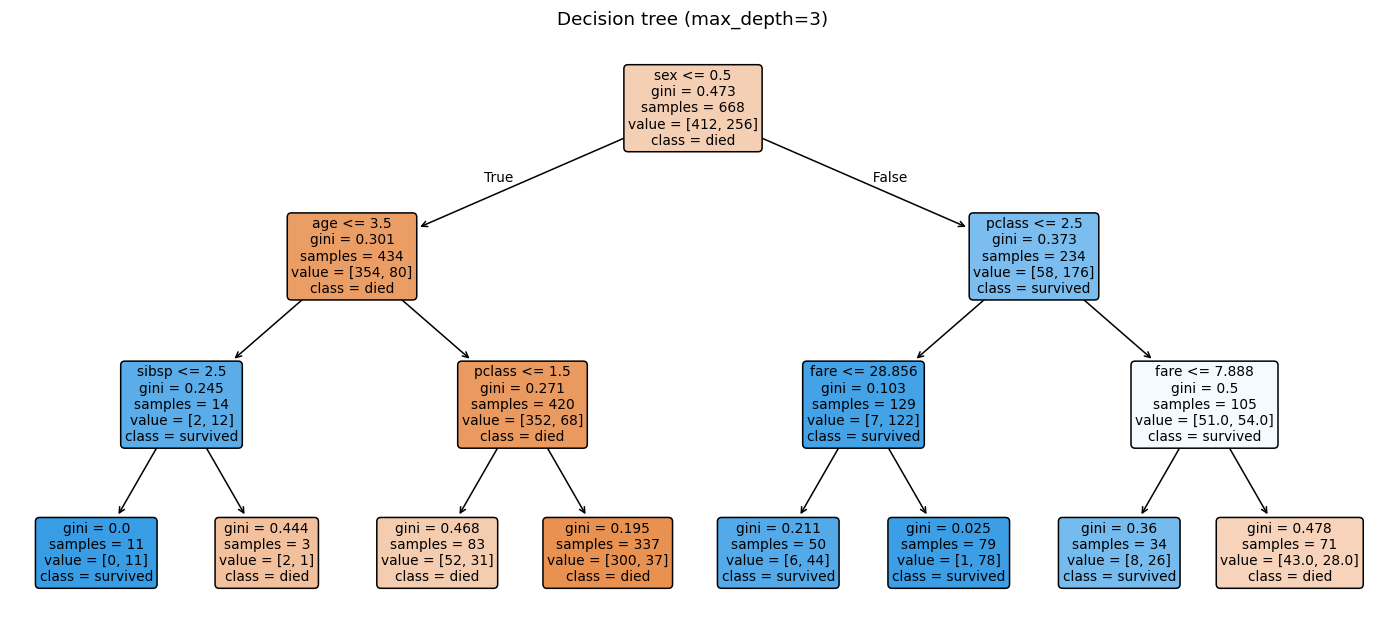

In [14]:
plt.figure(figsize=(16, 7))
plot_tree(tree, feature_names=list(X.columns), class_names=['died','survived'],
          filled=True, rounded=True, fontsize=9, impurity=True, proportion=False)
plt.title("Decision tree (max_depth=3)"); plt.show()